In [2]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
RANDOMSEED=1727

os.environ['PYTHONHASHSEED'] = str(RANDOMSEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:2"

In [3]:
import torch,random
import tensorflow as tf
import numpy as np

tf.config.experimental.enable_op_determinism()
torch.use_deterministic_algorithms(True)

def random_seed(seed=RANDOMSEED, use_cuda=False):
    np.random.seed(seed) # cpu vars
    torch.manual_seed(seed) # cpu vars
    random.seed(seed) # Python
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    
    if use_cuda: 
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # gpu vars
        torch.backends.cudnn.deterministic = True  #needed
        torch.backends.cudnn.benchmark = False
        
random_seed(RANDOMSEED)
tf.config.set_visible_devices([], 'GPU')

In [4]:
from pathlib import Path

cred_path = Path('~/.kaggle/access_token').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text("KGAT_9f6b15aaf6f7637b8497dfb3c56c079e")
    cred_path.chmod(0o600)

In [5]:
compName = Path('nlp-getting-started')

In [6]:
if not iskaggle:
    if not compName.exists():
        import zipfile,kaggle
        kaggle.api.competition_download_cli(str(compName))
        zipfile.ZipFile(f'{compName}.zip').extractall(compName)
else:
    # /kaggle/input/competitions/nlp-getting-started/train.csv
    compName = Path(f'/kaggle/input/competitions/{compName}')

# %pip install -q datasets
!dir /o:g /w {compName}
# !ls {compName}

 Volume in drive C is Windows
 Volume Serial Number is 6291-898F

 Directory of c:\Users\longnuub\learning-programming-languages\learning-python\kaggle\nlp-getting-started

[..]                    [.]                     test.csv
train.csv               sample_submission.csv   
               3 File(s)      1.431.241 bytes
               2 Dir(s)  136.688.705.536 bytes free


In [7]:
import pandas as pd
train=pd.read_csv(compName/"train.csv")
test=pd.read_csv(compName/"test.csv")

# drop the `id` col for training data ONLY, we need the id for test preds later
train.drop(columns=["id"],inplace=True)
train[27:41]

,keyword,location,text,target
27,NaN,NaN,Love my girlfriend,0
28,NaN,NaN,Cooool :),0
29,NaN,NaN,Do you like pasta?,0
30,NaN,NaN,The end!,0
31,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1
32,ablaze,Est. September 2012 - Bristol,We always try to bring the heavy. #metal #RT h...,0
33,ablaze,AFRICA,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1
34,ablaze,"Philadelphia, PA",Crying out for more! Set me ablaze,0
35,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0
36,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0


# feat engineering

In [8]:
train["keywordDefined"]=pd.Series([
  int(pd.notna(keyword)) for keyword in train["keyword"]
])
train["locationDefined"]=pd.Series([
  int(pd.notna(loc)) for loc in train["location"]
])
train[27:41]

,keyword,location,text,target,keywordDefined,locationDefined
27,NaN,NaN,Love my girlfriend,0,0,0
28,NaN,NaN,Cooool :),0,0,0
29,NaN,NaN,Do you like pasta?,0,0,0
30,NaN,NaN,The end!,0,0,0
31,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,1,1
32,ablaze,Est. September 2012 - Bristol,We always try to bring the heavy. #metal #RT h...,0,1,1
33,ablaze,AFRICA,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1,1,1
34,ablaze,"Philadelphia, PA",Crying out for more! Set me ablaze,0,1,1
35,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,1,1
36,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0,1,1


In [9]:
train["keywordInText"]=pd.Series([
	int(str(keyword).lower() in str(text).lower()) for keyword,text in zip(train["keyword"],train["text"])
])
train[27:41]

,keyword,location,text,target,keywordDefined,locationDefined,keywordInText
27,NaN,NaN,Love my girlfriend,0,0,0,0
28,NaN,NaN,Cooool :),0,0,0,0
29,NaN,NaN,Do you like pasta?,0,0,0,0
30,NaN,NaN,The end!,0,0,0,0
31,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1,1,1,1
32,ablaze,Est. September 2012 - Bristol,We always try to bring the heavy. #metal #RT h...,0,1,1,0
33,ablaze,AFRICA,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1,1,1,1
34,ablaze,"Philadelphia, PA",Crying out for more! Set me ablaze,0,1,1,1
35,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0,1,1,1
36,ablaze,Pretoria,@PhDSquares #mufc they've built so much hype a...,0,1,1,1


In [10]:
import re 

STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself',
    'they', 'them', 'their', 'theirs', 'themselves', 'a', 'an', 'and', 'are', 'as', 'at',
    'be', 'by', 'for', 'from', 'has', 'have', 'he', 'in', 'is', 'it', 'of', 'on', 'or',
    'that', 'the', 'this', 'to', 'was', 'were', 'will', 'with', 'but', 'not', 'so', 'than',
    'then', 'thence', 'there', 'these', 'they', 'this', 'those', 'through', 'thus', 'very',
    'just', 'don', 'dont', 'should', 'shouldve', 'now', 'theres', 'wasnt', 'werent'
])

def clean_text(text):
    """Clean and preprocess text without NLTK"""
    if pd.isna(text):
        return ""
    
    text = text.lower() # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'@(\w+)', '', text) # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text) # Remove hashtags (keep the word without @ or #)
    # text = re.sub(r'[^\w\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = ' '.join(text.split()) # Remove extra whitespace
    
    return text

def remove_stopwords(text):
    """Remove stopwords from text"""
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]
    return ' '.join(words)

In [11]:
# Basic text features
train["text_length"] = train["text"].str.len().fillna(0)
train["word_count"] = train["text"].str.split().str.len().fillna(0)

# Additional features (no external libraries)
train["capital_count"] = train["text"].str.findall(r'[A-Z]').str.len()
train["exclamation_count"] = train["text"].str.count('!')
train["question_count"] = train["text"].str.count('\\?')
train["hashtag_count"] = train["text"].str.count('#')
train["mention_count"] = train["text"].str.count('@')

# apply preproc
train["clean_text"] = train["text"].apply(clean_text)
train["clean_text"] = train["clean_text"].apply(remove_stopwords)

In [12]:
train

,keyword,location,text,target,keywordDefined,locationDefined,keywordInText,text_length,word_count,capital_count,exclamation_count,question_count,hashtag_count,mention_count,clean_text
0,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,0,0,0,69,13,10,0,0,1,0,deeds reason earthquake may allah forgive us all
1,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,0,0,0,38,7,5,0,0,0,0,forest fire near la ronge sask. canada
2,NaN,NaN,All residents asked to 'shelter in place' are ...,1,0,0,0,133,22,2,0,0,0,0,all residents asked 'shelter place' being noti...
3,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,0,0,0,65,8,1,0,0,1,0,", people receive wildfires evacuation orders c..."
4,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,0,0,0,88,16,3,0,0,2,0,got sent photo ruby alaska smoke wildfires pou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7608,NaN,NaN,Two giant cranes holding a bridge collapse int...,1,0,0,0,83,11,7,0,0,0,0,two giant cranes holding bridge collapse into ...
7609,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1,0,0,0,125,20,6,0,0,0,2,out control wild fires california even norther...
7610,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,0,0,0,65,8,10,0,1,0,0,m. [: utc]?km s volcano hawaii.
7611,NaN,NaN,Police investigating after an e-bike collided ...,1,0,0,0,137,19,4,0,0,0,0,police investigating after e-bike collided car...


# deep learning

prep data

In [13]:
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 8000  # Maximum number of words to keep
MAX_SEQUENCE_LENGTH = 100  # Maximum length of each text
EMBEDDING_DIM = 100  # Dimension of word embeddings

# Tokenize the text
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train["clean_text"])

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(train["clean_text"])
word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique words")

# Pad sequences to same length
X_seq = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# numerical feats
numeric_features = train[[
  "text_length", "word_count", "capital_count", 
  "exclamation_count", "question_count", 
  "hashtag_count", "mention_count", "keywordInText",
  "keywordDefined", "locationDefined"
]].fillna(0).values

# Combine features (we'll keep them separate for now)
y = train["target"].values

# Split data
X_seq_train, X_seq_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
  X_seq, numeric_features, y,
  test_size=0.2,
  random_state=RANDOMSEED,
  stratify=y,
)

Found 15134 unique words


combining text embeddings and numerical feats

In [14]:
from keras.models import Model
from keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Concatenate, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from keras.initializers import Zeros, GlorotUniform

# uniform_init=RandomUniform(minval=-65536, maxval=65536,seed=RANDOMSEED)
initializer=GlorotUniform(seed=RANDOMSEED)

# Text input branch
text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name='text_input')
embedding = Embedding(
  MAX_VOCAB_SIZE,
  EMBEDDING_DIM,
  embeddings_initializer=initializer, # consistency
)(text_input)
lstm_out = Bidirectional(LSTM(
  64,
  dropout=0.3,
  seed=RANDOMSEED, # seed for dropout
  kernel_initializer=initializer, # consistency
  bias_initializer=Zeros, # consistency
))(embedding)

# Numeric input branch
numeric_input = Input(shape=(numeric_features.shape[1],), name='numeric_input')
dense_numeric = Dense(
  32,
  activation='relu',
  kernel_initializer=initializer, # consistency
  bias_initializer=Zeros, # consistency
)(numeric_input)
dense_numeric = Dropout(0.3,seed=RANDOMSEED,)(dense_numeric)

# combine both branches
combined = Concatenate()([lstm_out, dense_numeric])
combined = Dense(
  64,
  activation='relu',
  kernel_regularizer=l2(0.01),
  kernel_initializer=initializer, # consistency
  bias_initializer=Zeros, # consistency
)(combined)
combined = Dropout(0.5,seed=RANDOMSEED,)(combined)
combined = Dense(
  32,
  activation='relu',
  kernel_initializer=initializer, # consistency
  bias_initializer=Zeros, # consistency
)(combined)
combined = Dropout(0.3,seed=RANDOMSEED,)(combined)
output = Dense(
  1,
  activation='sigmoid',
  name='output',
  kernel_initializer=initializer, # consistency
  bias_initializer=Zeros, # consistency
)(combined)

In [15]:
# create model
model_combined = Model(inputs=[text_input, numeric_input], outputs=output)
model_combined.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=["accuracy"]
)

In [16]:
model_combined.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    800,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        352 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     84,480 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 897,249 (3.42 MB)

 Trainable params: 897,249 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

train

In [17]:
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=3,
  restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
  monitor='val_loss',
  factor=0.5,
  patience=5,
  min_lr=0.00001,
  verbose=1
)

# Train with both features
history_combined = model_combined.fit(
    {'text_input': X_seq_train, 'numeric_input': X_num_train},
    y_train,
    validation_data=({'text_input': X_seq_val, 'numeric_input': X_num_val}, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=True,
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.5023 - loss: 1.7510 - val_accuracy: 0.5706 - val_loss: 0.9285 - learning_rate: 0.0010
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.5343 - loss: 0.9033 - val_accuracy: 0.5706 - val_loss: 0.8096 - learning_rate: 0.0010
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5456 - loss: 0.8070 - val_accuracy: 0.5706 - val_loss: 0.7661 - learning_rate: 0.0010
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.5567 - loss: 0.7659 - val_accuracy: 0.5706 - val_loss: 0.7460 - learning_rate: 0.0010
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.5688 - loss: 0.7491 - val_accuracy: 0.5706 - val_loss: 0.7353 - learning_rate: 0.0010
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5647 - loss: 0.7382 - val_accuracy: 0.5706 - val_loss: 0.7252 - learning_rate: 0.0010
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.5657 - loss

In [18]:
from sklearn.metrics import f1_score

# evaluate
y_pred_combined = (model_combined.predict([X_seq_val, X_num_val]) > 0.5).astype(int)
print(f"F1 Score: {f1_score(y_val, y_pred_combined)}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
F1 Score: 0.7845559845559845


<Axes: >

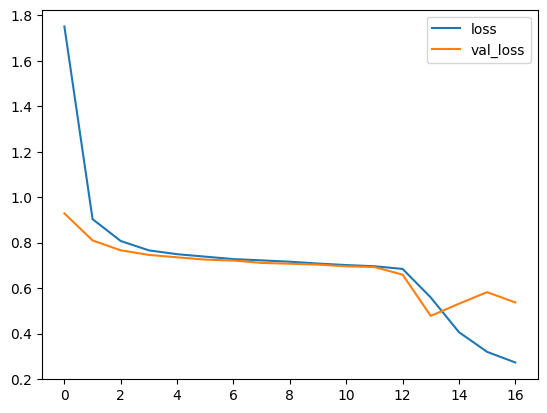

In [19]:
history_df = pd.DataFrame(history_combined.history)
history_df.loc[0:, ['loss', 'val_loss']].plot()
# history_df.to_csv("history_df.csv")

# predictions

feat engineering for test data

In [20]:
test["keywordDefined"]=pd.Series([
  int(pd.notna(keyword)) for keyword in train["keyword"]
])
test["locationDefined"]=pd.Series([
  int(pd.notna(loc)) for loc in train["location"]
])
test["keywordInText"]=pd.Series([
	int(str(keyword).lower() in str(text).lower()) for keyword,text in zip(test["keyword"],test["text"])
])

test["text_length"] = test["text"].str.len().fillna(0)
test["word_count"] = test["text"].str.split().str.len().fillna(0)

test["capital_count"] = test["text"].str.findall(r'[A-Z]').str.len()
test["exclamation_count"] = test["text"].str.count('!')
test["question_count"] = test["text"].str.count('\\?')
test["hashtag_count"] = test["text"].str.count('#')
test["mention_count"] = test["text"].str.count('@')

test["clean_text"] = test["text"].apply(clean_text)
test["clean_text"] = test["clean_text"].apply(remove_stopwords)

prep

In [21]:
# Prepare test data
test_sequences = tokenizer.texts_to_sequences(test["clean_text"])
test_seq_padded = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Prepare test numeric features
test_numeric = test[[
    "text_length", "word_count", "capital_count", 
    "exclamation_count", "question_count", 
    "hashtag_count", "mention_count", "keywordInText",
    "keywordDefined", "locationDefined"
]].fillna(0).values

predict

In [22]:
preds = (model_combined.predict([test_seq_padded, test_numeric]) > 0.5).astype(int).flatten()

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [23]:
print(f"Unique prediction values: {np.unique(preds)}")

Unique prediction values: [0 1]


In [24]:
subs_df=pd.DataFrame({
  "ID":test["id"],
  "Target":preds,
})

In [25]:
# subs_df.head()
subs_df.shape

(3263, 2)

In [26]:
subs_df.to_csv("submission.csv",index=False)